##Libs imports


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata

## Data Import

In [ ]:
def data_import(csv_path):
  drive.mount('/content/drive')
  df = pd.read_csv(csv_path)
  return df

## Análise Firmográfica

In [ ]:
def extrair_estado(local):
  if pd.isna(local):
      return None

  # Casos com vírgula + estado escrito por extenso
  if "," in local:
      partes = [p.strip() for p in local.split(",")]
      ultimo = partes[-1]

      # Se for sigla de estado brasileiro (SP, RJ, MG, etc.)
      if re.match(r'^[A-Z]{2}$', ultimo):
          return ultimo

      # Se for "São Paulo, São Paulo" -> pega só "SP"
      if "São Paulo" in ultimo:
          return "SP"
      if "Minas Gerais" in ultimo:
          return "MG"
      if "Paraná" in ultimo:
          return "PR"
      if "Rio de Janeiro" in ultimo:
          return "RJ"
      if "Santa Catarina" in ultimo:
          return "SC"
      if "Rio Grande do Sul" in ultimo:
          return "RS"
      if "Espírito Santo" in ultimo:
          return "ES"

      # Se for outros países, retorna o próprio texto
      return ultimo

  # Casos soltos tipo "New York" ou "Paris"
  return local

In [ ]:
def firmographics(df_processed):
    print("\n=== 6.1 Análise Exploratória da Base ===")
    print(f"📊 Total de empresas após pré-processamento: {len(df_processed)}")

    print("\n--- Distribuição por Estado ---")
    print(df_processed['estado'].value_counts())

    print("\n--- Distribuição por Segmento ---")
    print(df_processed['segmento'].value_counts())

    print("\n--- Estatísticas de Capital Social ---")
    print(df_processed['capital_social'].describe())

    print("\n--- Estatísticas de Funcionários ---")
    print(df_processed['funcionários'].describe())



## Pre-process

In [ ]:
def normalize(s: str) -> str:
    if s is None:
        return ""
    s = unicodedata.normalize('NFKD', str(s))
    s = ''.join(ch for ch in s if not unicodedata.combining(ch))
    return s.strip().lower()

UFS_BR = {
    "AC","AL","AM","AP","BA","CE","DF","ES","GO","MA","MG","MS","MT",
    "PA","PB","PE","PI","PR","RJ","RN","RO","RR","RS","SC","SE","SP","TO"
}

NOME_TO_UF = {
    "acre":"AC","alagoas":"AL","amapa":"AP","amazonas":"AM","bahia":"BA","ceara":"CE",
    "distrito federal":"DF","espirito santo":"ES","goias":"GO","maranhao":"MA",
    "mato grosso":"MT","mato grosso do sul":"MS","minas gerais":"MG","para":"PA",
    "paraiba":"PB","pernambuco":"PE","piaui":"PI","parana":"PR","rio de janeiro":"RJ",
    "rio grande do norte":"RN","rio grande do sul":"RS","rondonia":"RO","roraima":"RR",
    "santa catarina":"SC","sao paulo":"SP","sergipe":"SE","tocantins":"TO"
}

def parse_localizacao(s: str):
    """Recebe string da coluna 'localização' e devolve (cidade, UF_BR_ou_None)."""
    if not s or str(s).strip() == "":
        return (None, None)
    raw = str(s).strip()
    # quebra por vírgula ou hífen: "Cidade, UF" | "Cidade - Estado"
    tokens = [t.strip() for t in re.split(r'[,|-]+', raw) if t.strip()]
    if not tokens:
        return (None, None)

    cidade = tokens[0]
    # Tenta UF de 2 letras
    ultima = tokens[-1].upper()
    if ultima in UFS_BR:
        return (cidade, ultima)

    # Tenta nome por extenso (normalizado)
    for tok in reversed(tokens):
        uf = NOME_TO_UF.get(normalize(tok))
        if uf:
            return (cidade, uf)

    return (cidade, None)


In [ ]:
def pre_process(df):
  print("--- Início do Pré-processamento (ajustado às suas colunas) ---")

  # =========================
  # 1) Renomear colunas
  # =========================
  df.columns = (df.columns
                .str.lower()
                .str.strip()
                .str.replace(' ', '_')
                .str.replace('unnamed:_14', 'unnamed_col'))
  print(f"\nColunas após renomear: {df.columns.tolist()}")

  # Esperadas após renomear (pelo seu CSV):
  # ['empresa','razão_social','cnpj','capital_social','intervalo_de_capital',
  #  'segmento','funcionários','intervalo_de_funcionários','localização',
  #  'descrição','linkedin','unique_segmento','contagme_do_segmento','top_20_segmentos','unnamed_col']

  # =========================
  # 2) Remover colunas inelegíveis / ruído
  # =========================
  noise_to_drop = [
      # identificadores/controle que não entram como feature
      'empresa', 'razão_social', 'cnpj',
      # auxiliares/textos/urls/datas
      'intervalo_de_capital', 'intervalo_de_funcionários',
      'descrição', 'linkedin', 'unique_segmento', 'contagme_do_segmento',
      'top_20_segmentos', 'unnamed_col'
  ]
  cols_present = [c for c in noise_to_drop if c in df.columns]
  df_processed = df.drop(columns=cols_present, errors='ignore').copy()
  print(f"\nColunas removidas (ruído/inelegíveis): {cols_present}")

  # =========================
  # 3) Separar 'localização' em cidade/estado e manter apenas 'estado'
  # =========================
  if 'localização' in df_processed.columns:
      # Apply loc_norm to each element in the 'localização' column
      parsed = df_processed['localização'].apply(parse_localizacao)
      df_processed['cidade'] = parsed.map(lambda x: x[0])
      df_processed['estado'] = parsed.map(lambda x: x[1])
      df_processed.drop(columns=['localização'], inplace=True)
      print("Coluna 'localização' separada em 'cidade' e 'estado'.")


  # descartamos 'cidade' por alta cardinalidade
  if 'cidade' in df_processed.columns:
      df_processed.drop(columns=['cidade'], inplace=True)

  # =========================
  # 4) Limpeza / conversão da coluna 'capital_social'
  # =========================
  if 'capital_social' in df_processed.columns:
      df_processed['capital_social'] = (
          df_processed['capital_social'].astype(str)
          .str.replace(',', '', regex=False)   # remove separador de milhar
          .str.replace('.00', '', regex=False) # remove sufixo decimal fixo
      )
      df_processed['capital_social'] = pd.to_numeric(df_processed['capital_social'], errors='coerce')
      print("Coluna 'capital_social' limpa e convertida para numérica.")
  else:
      print("Coluna 'capital_social' não encontrada.")

  # =========================
  # 5) Limpeza / conversão da coluna 'funcionários'
  # =========================
  if 'funcionários' in df_processed.columns:
      df_processed['funcionários'] = (
          df_processed['funcionários'].astype(str)
          .str.replace(',', '', regex=False)   # remove separador de milhar
          .str.replace('.00', '', regex=False) # se aparecer
      )
      df_processed['funcionários'] = pd.to_numeric(df_processed['funcionários'], errors='coerce')
      print("Coluna 'funcionários' limpa e convertida para numérica.")
  else:
      print("Coluna 'funcionários' não encontrada.")

  # =========================
  # 6) Definir features numéricas e categóricas (lista CURADA)
  # =========================
  numerical_features = [c for c in ['capital_social', 'funcionários'] if c in df_processed.columns]

  # categóricas relevantes no seu CSV:
  allowed_categoricals = ['estado', 'segmento']
  categorical_features = [c for c in allowed_categoricals if c in df_processed.columns]

  # Colunas fora do modelo (para você revisar)
  used = set(numerical_features + categorical_features)
  leftover = [c for c in df_processed.columns if c not in used]
  if leftover:
      print(f"\nColunas ignoradas (fora do modelo): {leftover}")

  print(f"\nColunas numéricas para processamento: {numerical_features}")
  print(f"Colunas categóricas para processamento: {categorical_features}")

  # =========================
  # 7) Pipelines de transformação
  # =========================
  numerical_transformer = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='median')),
      ('scaler', StandardScaler())
  ])
  categorical_transformer = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
  ])

  # =========================
  # 8) ColumnTransformer
  # =========================
  preprocessor = ColumnTransformer(transformers=[
      ('num', numerical_transformer, numerical_features),
      ('cat', categorical_transformer, categorical_features)
  ], remainder='drop')

  # =========================
  # 9) Aplicar transformação
  # =========================
  X_processed = preprocessor.fit_transform(df_processed)

  print(f"\nShape do dataset vetorizado: {X_processed.shape}")
  print("Exemplo das primeiras 5 linhas (parcial):")
  print(X_processed[:5, :5])

  # =========================
  # 10) DataFrame com nomes de features (para auditoria)
  # =========================
  ohe_feature_names = []
  if categorical_features:
      ohe_feature_names = preprocessor.named_transformers_['cat']['onehot']\
                          .get_feature_names_out(categorical_features).tolist()

  all_feature_names = numerical_features + ohe_feature_names
  X_df_processed = pd.DataFrame(X_processed, columns=all_feature_names)


  print("\n--- Pré-processamento Concluído ---")
  return df_processed, X_processed, X_df_processed

##One-Class Classification (OCC)

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler here
from sklearn.neighbors import NearestNeighbors # Import NearestNeighbors here

def occ(df_processed, X_processed):
  # --- 3.1. One-Class Classification (OCC) ---

  # Modelo 1: One-Class SVM
  print("\n--- Modelo One-Class SVM (OCC) ---")
  oc_svm = OneClassSVM(kernel='rbf', nu=0.05, gamma='auto')
  oc_svm.fit(X_processed)

  oc_svm_scores = oc_svm.decision_function(X_processed)

  print(f"Mínimo score One-Class SVM: {oc_svm_scores.min():.4f}")
  print(f"Máximo score One-Class SVM: {oc_svm_scores.max():.4f}")
  print(f"Média score One-Class SVM: {oc_svm_scores.mean():.4f}")

  oc_svm_predictions = oc_svm.predict(X_processed)
  num_anomalies_ocsvm = np.sum(oc_svm_predictions == -1)
  print(f"Empresas classificadas como 'anomalias' pelo One-Class SVM: {num_anomalies_ocsvm} de {len(X_processed)}")

  plt.figure(figsize=(10, 5))
  sns.histplot(oc_svm_scores, bins=50, kde=True, color='skyblue')
  plt.title('Distribuição dos Scores de Decisão do One-Class SVM')
  plt.xlabel('Score de Decisão')
  plt.ylabel('Contagem')
  plt.grid(True)
  plt.show()

  # Modelo 2: Isolation Forest
  print("\n--- Modelo Isolation Forest (OCC) ---")
  iso_forest = IsolationForest(contamination=0.05,  random_state=42)
  iso_forest.fit(X_processed)

  iso_forest_scores = iso_forest.decision_function(X_processed)

  print(f"Mínimo score Isolation Forest: {iso_forest_scores.min():.4f}")
  print(f"Máximo score Isolation Forest: {iso_forest_scores.max():.4f}")
  print(f"Média score Isolation Forest: {iso_forest_scores.mean():.4f}")

  iso_forest_predictions = iso_forest.predict(X_processed)
  num_anomalies_isoforest = np.sum(iso_forest_predictions == -1)
  print(f"Empresas classificadas como 'anomalias' pelo Isolation Forest: {num_anomalies_isoforest} de {len(X_processed)}")

  plt.figure(figsize=(10, 5))
  sns.histplot(iso_forest_scores, bins=50, kde=True, color='lightcoral')
  plt.title('Distribuição dos Scores de Decisão do Isolation Forest')
  plt.xlabel('Score de Decisão')
  plt.ylabel('Contagem')
  plt.grid(True)
  plt.show()
  # Return iso_forest_predictions so it can be used in the next step
  return oc_svm_scores, iso_forest_scores, iso_forest_predictions

## Distance-Based Scoring (DBS) - INLINERS + OUTLIERS


In [ ]:
# # --- 3.2. Distance-Based Scoring (DBS) ---

# print("\n--- Distância para o Centróide do ICP (DBS) ---")
# icp_centroid = np.mean(X_processed, axis=0)
# dbs_centroid_distances = np.linalg.norm(X_processed - icp_centroid, axis=1)

# scaler_dbs_centroid = MinMaxScaler(feature_range=(0, 1))
# dbs_centroid_scores = 1 - scaler_dbs_centroid.fit_transform(dbs_centroid_distances.reshape(-1, 1)).flatten()

# plt.figure(figsize=(10, 5))
# sns.histplot(dbs_centroid_scores, bins=50, kde=True, color='lightgreen')
# plt.title('Distribuição dos Scores de Distância para o Centróide (Normalizado)')
# plt.xlabel('Score de Distância')
# plt.ylabel('Contagem')
# plt.grid(True)
# plt.show()

# # k-NN
# print(f"\n--- Distância Média para os k Vizinhos Mais Próximos (k-NN) (DBS) ---")
# k = 10
# nn_model = NearestNeighbors(n_neighbors=k + 1, algorithm='auto')
# nn_model.fit(X_processed)
# distances, indices = nn_model.kneighbors(X_processed)
# dbs_knn_distances = np.mean(distances[:, 1:], axis=1)

# scaler_dbs_knn = MinMaxScaler(feature_range=(0, 1))
# dbs_knn_scores = 1 - scaler_dbs_knn.fit_transform(dbs_knn_distances.reshape(-1, 1)).flatten()

# plt.figure(figsize=(10, 5))
# sns.histplot(dbs_knn_scores, bins=50, kde=True, color='lightsalmon')
# plt.title(f'Distribuição dos Scores de Distância Média k-NN (k={k}, Normalizado)')
# plt.xlabel('Score de Distância')
# plt.ylabel('Contagem')
# plt.grid(True)
# plt.show()


##Distance-Based Scoring (DBS) - INLINERS


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors

def dbs(oc_svm_scores, iso_forest_scores, X_processed, df_processed, iso_forest_predictions):
  # --- 3.2. Distance-Based Scoring (DBS) com Filtro do Isolation Forest ---

  print("\n--- DBS aplicado somente aos Inliers do Isolation Forest ---")

  # Máscara de inliers segundo Isolation Forest
  inlier_mask = iso_forest_predictions == 1
  X_inliers = X_processed[inlier_mask]

  # Inicializa os arrays de scores com NaN
  dbs_centroid_scores = np.full(X_processed.shape[0], np.nan)
  dbs_knn_scores = np.full(X_processed.shape[0], np.nan)

  # --- DBS - Distância ao centróide ---
  icp_centroid = np.mean(X_inliers, axis=0)
  centroid_distances = np.linalg.norm(X_inliers - icp_centroid, axis=1)
  scaler_centroid = MinMaxScaler() # Use a local scaler
  scaled_centroid_scores = 1 - scaler_centroid.fit_transform(centroid_distances.reshape(-1, 1)).flatten()
  dbs_centroid_scores[inlier_mask] = scaled_centroid_scores

  print(f"Score centróide aplicado a {len(X_inliers)} inliers.")
  print(f"Média dos scores centróide (normalizado): {np.nanmean(dbs_centroid_scores):.4f}")

  plt.figure(figsize=(10, 5))
  sns.histplot(dbs_centroid_scores[~np.isnan(dbs_centroid_scores)], bins=50, kde=True, color='lightgreen')
  plt.title('Distribuição dos Scores de Distância para o Centróide (Inliers - Isolation Forest)')
  plt.xlabel('Score de Distância')
  plt.ylabel('Contagem')
  plt.grid(True)
  plt.show()

  # --- DBS - k-NN (entre os inliers) ---
  k = 10
  print(f"Calculando distância média para os {k} vizinhos mais próximos (entre inliers)...")
  nn_model = NearestNeighbors(n_neighbors=k + 1)
  nn_model.fit(X_inliers)
  distances, indices = nn_model.kneighbors(X_inliers)
  avg_knn_distances = np.mean(distances[:, 1:], axis=1)
  scaler_knn = MinMaxScaler() # Use a local scaler
  scaled_knn_scores = 1 - scaler_knn.fit_transform(avg_knn_distances.reshape(-1, 1)).flatten()
  dbs_knn_scores[inlier_mask] = scaled_knn_scores

  print(f"Score k-NN aplicado a {len(X_inliers)} inliers.")
  print(f"Média dos scores k-NN (normalizado): {np.nanmean(dbs_knn_scores):.4f}")

  plt.figure(figsize=(10, 5))
  sns.histplot(dbs_knn_scores[~np.isnan(dbs_knn_scores)], bins=50, kde=True, color='lightsalmon')
  plt.title(f'Distribuição dos Scores de Distância Média k-NN (k={k}, Inliers - Isolation Forest)')
  plt.xlabel('Score de Distância')
  plt.ylabel('Contagem')
  plt.grid(True)
  plt.show()
  return dbs_centroid_scores, dbs_knn_scores

## Ranking Híbrido

In [ ]:
def ranking(df, oc_svm_scores, iso_forest_scores, dbs_centroid_scores, dbs_knn_scores,
            w_centroid=0.8, w_knn=0.2, outlier_policy="nan"):
    """
    outlier_policy: 'nan' -> media_final = NaN para outliers
                    'zero' -> media_final = 0 para outliers
    """
    print("\n--- Criando DataFrame com todos os scores ---")
    scores_df = pd.DataFrame({
        'razão_social': df['razão_social'] if 'razão_social' in df.columns else np.arange(len(oc_svm_scores)),
        'empresa': df['empresa'] if 'empresa' in df.columns else np.arange(len(oc_svm_scores)),
        'oc_svm_score': oc_svm_scores,
        'iso_forest_score': iso_forest_scores,
        'dbs_centroid_score': dbs_centroid_scores,
        'dbs_knn_score': dbs_knn_scores
    })

    # Inlier = tem ambos DBS válidos
    inlier_mask = scores_df['dbs_centroid_score'].notna() & scores_df['dbs_knn_score'].notna()

    print("\nResumo estatístico dos scores:")
    display(scores_df.describe())

    # Score final: só DBS (ponderado). OCC não entra no ranking.
    scores_df.loc[inlier_mask, 'media_final'] = (
        w_centroid * scores_df.loc[inlier_mask, 'dbs_centroid_score'] +
        w_knn * scores_df.loc[inlier_mask, 'dbs_knn_score']
    )

    # Política para outliers
    if outlier_policy == "zero":
        scores_df.loc[~inlier_mask, 'media_final'] = 0.0
    else:  # 'nan'
        scores_df.loc[~inlier_mask, 'media_final'] = np.nan

    top_n = 10
    print(f"\n🏆 Top {top_n} empresas com maior score final (apenas inliers):")
    display(
        scores_df.loc[inlier_mask, ['empresa', 'media_final']]
                 .sort_values(by='media_final', ascending=False)
                 .reset_index(drop=True)
                 .head(top_n)
    )
    return scores_df

## Diagnóstico

In [ ]:
def diagnostico(scores_df, X_processed, df_processed):
    # --- 4. Diagnóstico ---

  print("\n--- EXPLICABILIDADE DO MODELO ---")

  # ========================================
  # 1. PROJEÇÃO PCA COLORIDA POR SCORE FINAL
  # ========================================

  print("\n🧠 Visualização 1: Projeção PCA com Cores por Score Final")
  print("Este gráfico mostra uma redução de dimensionalidade do dataset vetorizado (PCA),")
  print("permitindo visualizar se há agrupamento natural entre empresas de alto e baixo score final.")
  print("As cores representam o valor do score final médio de cada empresa.")

  # PCA
  pca = PCA(n_components=2)
  X_pca = pca.fit_transform(X_processed)

  plt.figure(figsize=(10, 6))
  sns.scatterplot(
      x=X_pca[:, 0], y=X_pca[:, 1],
      hue=scores_df['media_final'], # 'media_final' is now in scores_df
      palette='viridis',
      edgecolor='black',
      alpha=0.8
  )
  plt.title("Projeção PCA do Dataset Colorido por Score Final")
  plt.xlabel("Componente Principal 1")
  plt.ylabel("Componente Principal 2")
  plt.grid(True)
  plt.legend(title="Score ICP")
  plt.show()


  # ====================================================
  # 2. BOXPLOT DE FUNCIONÁRIOS POR TERÇO DE SCORE FINAL
  # ====================================================

  print("\n🧠 Visualização 2: Boxplot de Funcionários por Faixa de Score")
  print("Este gráfico compara a quantidade de funcionários das empresas agrupadas em três faixas:")
  print("Baixo, Médio e Alto score final.")
  print("Ele ajuda a investigar se empresas com muitos ou poucos funcionários tendem a ser ICPs.")

  # Agrupar por tercis de score
  scores_df['tercil'] = pd.qcut(scores_df['media_final'], 3, labels=['Baixo', 'Médio', 'Alto'])

  # Merge scores_df with df_processed to get the 'funcionários' column
  scores_df_merged = pd.merge(scores_df, df_processed[['funcionários']], left_index=True, right_index=True, how='left')


  plt.figure(figsize=(10, 5))
  sns.boxplot(data=scores_df_merged, x='tercil', y='funcionários') # Use scores_df_merged
  plt.title("Distribuição de Funcionários por Grupo de Score ICP")
  plt.xlabel("Grupo de Score Final")
  plt.ylabel("Número de Funcionários")
  plt.grid(True)
  plt.show()


  # ============================================
  # 3. TABELA DE EXTREMOS: TOP 5 E BOTTOM 5 ICPs
  # ============================================

  print("\n🧠 Visualização 3: Empresas com Maiores e Menores Scores")
  print("Essas tabelas mostram as 5 empresas com maior score final (ICP mais forte)")
  print("e as 5 com menor score final (possíveis outliers ou menos alinhadas ao perfil ideal).")

  print("\n📈 Top 5 empresas ICP:")
  display(scores_df_merged[['empresa', 'media_final']].sort_values(by='media_final', ascending=False).head(5)) # Use scores_df_merged and 'empresa'

  print("\n📉 Bottom 5 empresas (possíveis outliers):")
  display(scores_df_merged[['empresa', 'media_final']].sort_values(by='media_final', ascending=True).head(5)) # Use scores_df_merged and 'empresa'

## Main

In [ ]:
def run_icp_analysis(csv_file_path):
    """
    Executes the complete ICP analysis workflow.

    Args:
        csv_file_path (str): The path to the input CSV file.
    """
    print(f"Starting ICP analysis for: {csv_file_path}")

    df = data_import(csv_file_path)


    df_processed, X_processed, X_df_processed = pre_process(df)

    firmographics(df_processed)

    # occ now returns iso_forest_predictions
    oc_svm_scores, iso_forest_scores, iso_forest_predictions = occ(df_processed, X_processed)

    # Pass iso_forest_predictions to dbs
    try:
        dbs_centroid_scores, dbs_knn_scores = dbs(oc_svm_scores, iso_forest_scores, X_processed, df_processed, iso_forest_predictions)
    except NameError:
        print("Erro: Variável 'iso_forest_predictions' não encontrada. Certifique-se que a função 'occ' a retorna ou a torna global.")
        pass

    # Certifique-se que todas as variáveis de score necessárias estão disponíveis
    try:
        # ranking function needs df_processed to get 'razão_social' and 'empresa'
        scores_df = ranking(df, oc_svm_scores, iso_forest_scores, dbs_centroid_scores, dbs_knn_scores)
    except NameError as e:
        print(f"Erro ao executar ranking: {e}. Certifique-se que todas as variáveis de score foram criadas e estão acessíveis.")

    # Certifique-se que scores_df está disponível globalmente ou passe como argumento
    try:
        # Pass scores_df, X_processed, df_processed to diagnostico
        diagnostico(scores_df, X_processed, df_processed)
    except NameError:
        print("Erro: Variável 'scores_df' não encontrada. Certifique-se que a função 'ranking' a retorna ou a torna global.")
        pass

    print("\nFluxo completo executado.")

## Empresas


Starting ICP analysis for: /content/drive/MyDrive/TCC/Dados/Gympass Data/Gympass Data.csv
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Início do Pré-processamento (ajustado às suas colunas) ---

Colunas após renomear: ['empresa', 'razão_social', 'cnpj', 'capital_social', 'intervalo_de_capital', 'segmento', 'funcionários', 'intervalo_de_funcionários', 'localização', 'descrição', 'linkedin', 'unique_segmento', 'contagme_do_segmento', 'top_20_segmentos', 'unnamed_col']

Colunas removidas (ruído/inelegíveis): ['empresa', 'razão_social', 'cnpj', 'intervalo_de_capital', 'intervalo_de_funcionários', 'descrição', 'linkedin', 'unique_segmento', 'contagme_do_segmento', 'top_20_segmentos', 'unnamed_col']
Coluna 'localização' separada em 'cidade' e 'estado'.
Coluna 'capital_social' limpa e convertida para numérica.
Coluna 'funcionários' limpa e convertida para numérica.

Colunas numéricas para processamento: ['

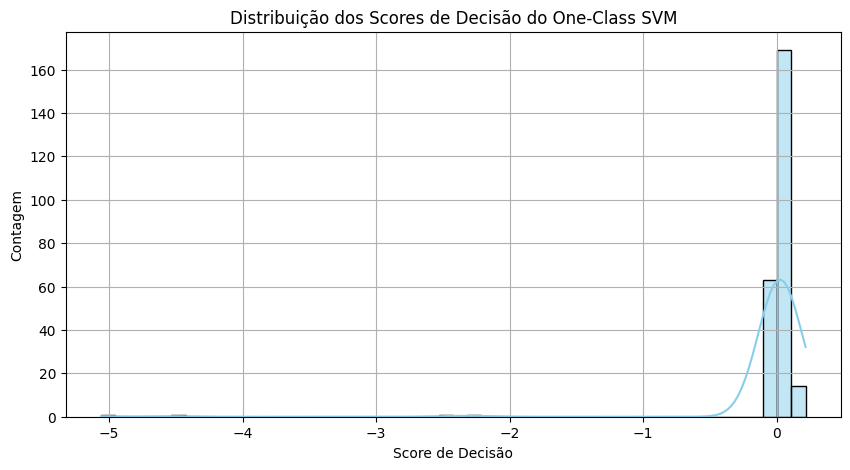


--- Modelo Isolation Forest (OCC) ---
Mínimo score Isolation Forest: -0.0264
Máximo score Isolation Forest: 0.0319
Média score Isolation Forest: 0.0163
Empresas classificadas como 'anomalias' pelo Isolation Forest: 13 de 250


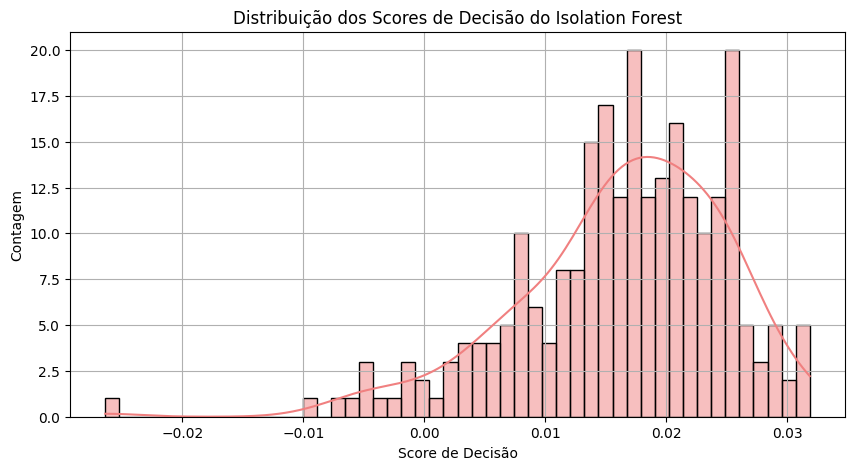


--- DBS aplicado somente aos Inliers do Isolation Forest ---
Score centróide aplicado a 237 inliers.
Média dos scores centróide (normalizado): 0.9672


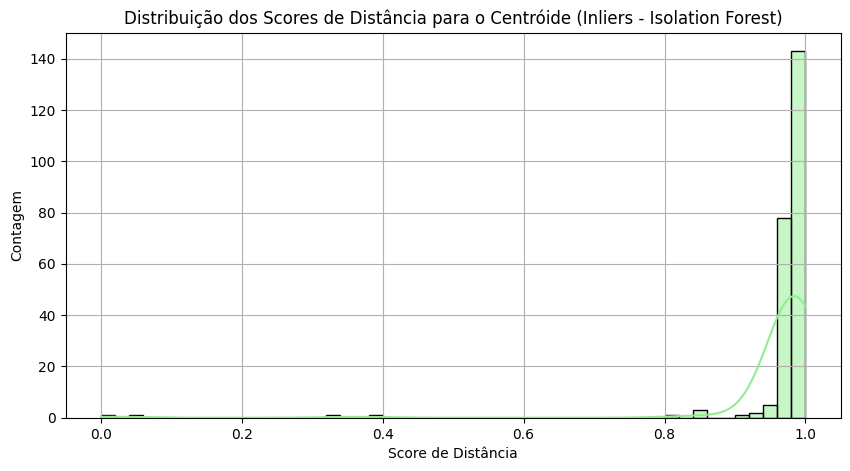

Calculando distância média para os 10 vizinhos mais próximos (entre inliers)...
Score k-NN aplicado a 237 inliers.
Média dos scores k-NN (normalizado): 0.8894


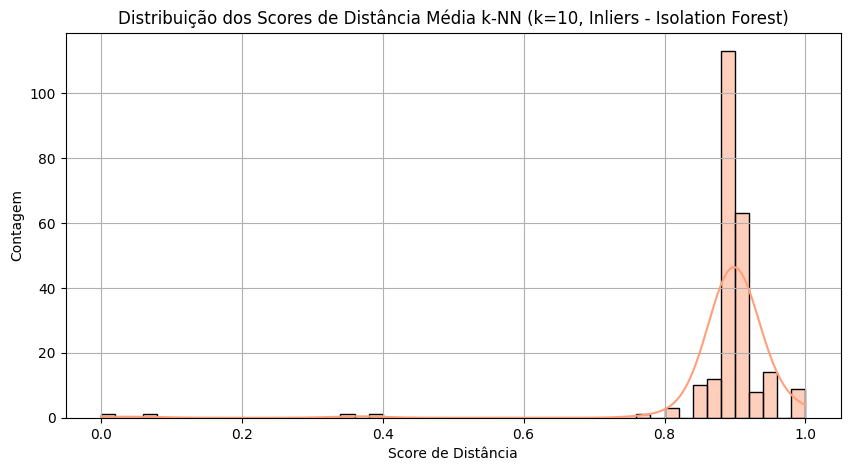


--- Criando DataFrame com todos os scores ---

Resumo estatístico dos scores:


,oc_svm_score,iso_forest_score,dbs_centroid_score,dbs_knn_score
count,250.000000,250.000000,237.000000,237.000000
mean,-0.028820,0.016321,0.967159,0.889402
std,0.479908,0.008643,0.106793,0.098273
min,-5.061097,-0.026373,0.000000,0.000000
25%,0.005031,0.011844,0.967635,0.894562
50%,0.011038,0.017559,0.981794,0.894916
75%,0.033341,0.022444,0.995014,0.908414
max,0.217128,0.031851,1.000000,1.000000



🏆 Top 10 empresas com maior score final (apenas inliers):


,empresa,media_final
0,Sprinklr,0.998734
1,Azos Labs,0.998734
2,DigiBee,0.998630
3,Hexagon Events Pvt Ltd,0.998627
4,Rocket Lawyer,0.998572
5,SmartBreed AG,0.998505
6,Linkcom Telecom LTD,0.998495
7,Capco,0.998448
8,London Internet Exchange (LINX),0.997556
9,CI&T,0.990266



--- EXPLICABILIDADE DO MODELO ---

🧠 Visualização 1: Projeção PCA com Cores por Score Final
Este gráfico mostra uma redução de dimensionalidade do dataset vetorizado (PCA),
permitindo visualizar se há agrupamento natural entre empresas de alto e baixo score final.
As cores representam o valor do score final médio de cada empresa.


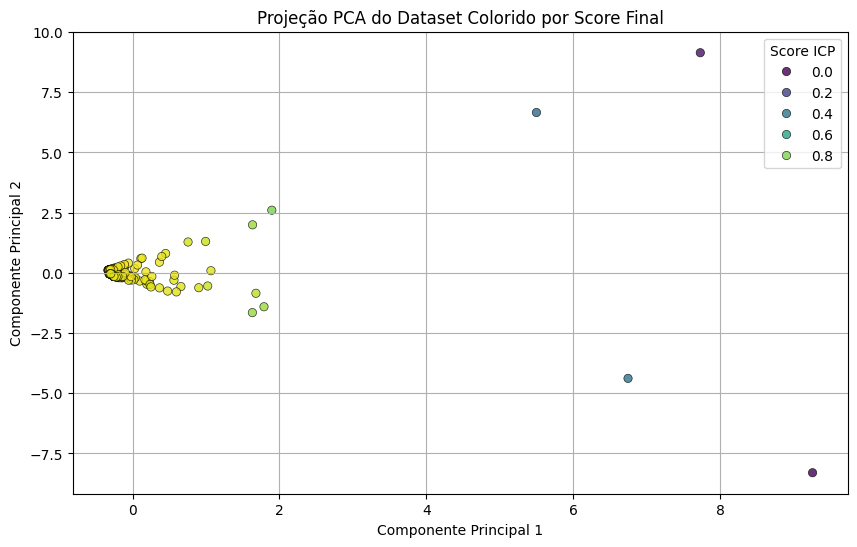


🧠 Visualização 2: Boxplot de Funcionários por Faixa de Score
Este gráfico compara a quantidade de funcionários das empresas agrupadas em três faixas:
Baixo, Médio e Alto score final.
Ele ajuda a investigar se empresas com muitos ou poucos funcionários tendem a ser ICPs.


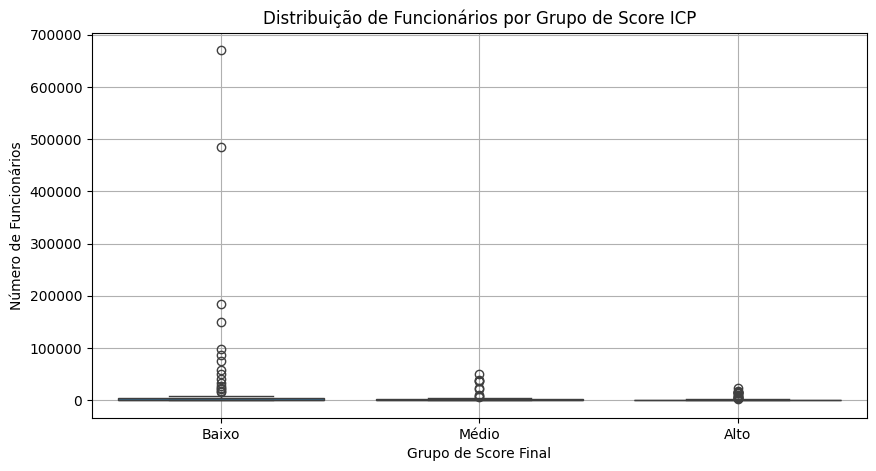


🧠 Visualização 3: Empresas com Maiores e Menores Scores
Essas tabelas mostram as 5 empresas com maior score final (ICP mais forte)
e as 5 com menor score final (possíveis outliers ou menos alinhadas ao perfil ideal).

📈 Top 5 empresas ICP:


,empresa,media_final
183,Sprinklr,0.998734
20,Azos Labs,0.998734
89,DigiBee,0.998630
120,Hexagon Events Pvt Ltd,0.998627
53,Rocket Lawyer,0.998572



📉 Bottom 5 empresas (possíveis outliers):


,empresa,media_final
190,Itaú Unibanco,0.000000
18,Tata Consultancy Services,0.047859
56,Deloitte,0.338858
170,Ambev,0.385614
39,DHL,0.797015



Fluxo completo executado.


In [ ]:
#GYMPASS
csv_file_path = '/content/drive/MyDrive/TCC/Dados/Gympass Data/Gympass Data.csv'
run_icp_analysis(csv_file_path)

Starting ICP analysis for: /content/drive/MyDrive/TCC/Dados/TotalPass/TotalPass Data.csv
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Início do Pré-processamento (ajustado às suas colunas) ---

Colunas após renomear: ['empresa', 'razão_social', 'cnpj', 'capital_social', 'intervalo_de_capital', 'segmento', 'funcionários', 'intervalo_de_funcionários', 'localização', 'job_industry_collection', 'job_functions_collection', 'unique_segmento', 'contagem_de_segmento', 'top_segmentos', 'unnamed_col']

Colunas removidas (ruído/inelegíveis): ['empresa', 'razão_social', 'cnpj', 'intervalo_de_capital', 'intervalo_de_funcionários', 'unique_segmento', 'unnamed_col']
Coluna 'localização' separada em 'cidade' e 'estado'.
Coluna 'capital_social' limpa e convertida para numérica.
Coluna 'funcionários' limpa e convertida para numérica.

Colunas ignoradas (fora do modelo): ['job_industry_collection', 'job_functions_coll

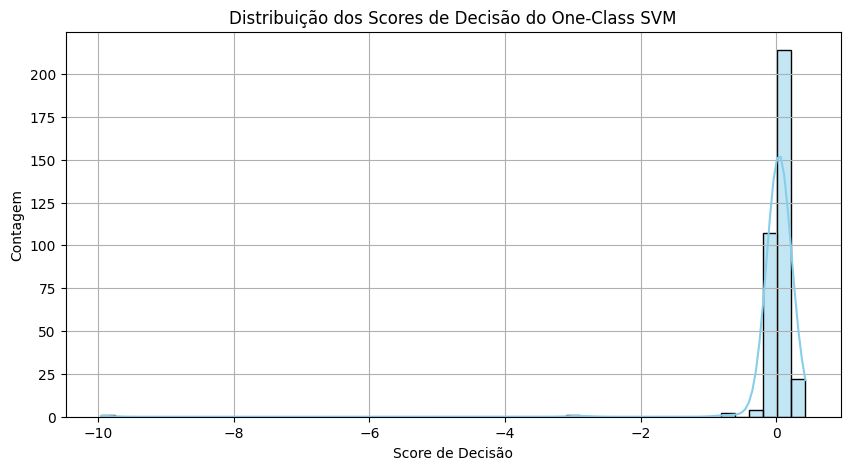


--- Modelo Isolation Forest (OCC) ---
Mínimo score Isolation Forest: -0.0119
Máximo score Isolation Forest: 0.0338
Média score Isolation Forest: 0.0187
Empresas classificadas como 'anomalias' pelo Isolation Forest: 18 de 351


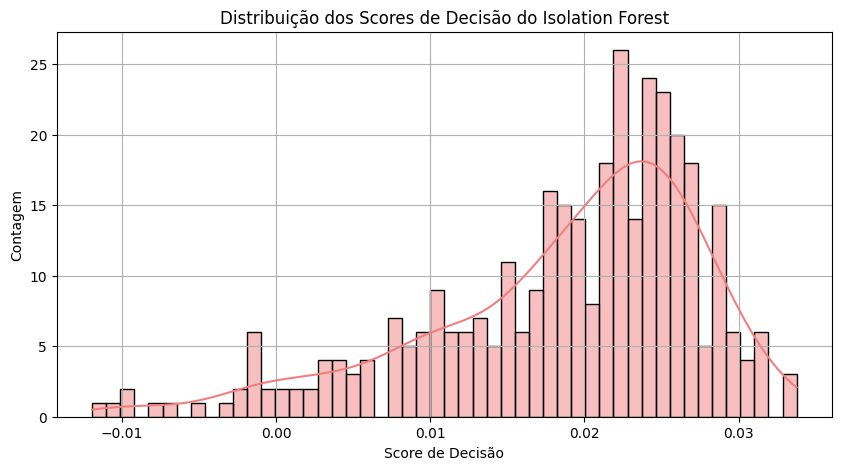


--- DBS aplicado somente aos Inliers do Isolation Forest ---
Score centróide aplicado a 333 inliers.
Média dos scores centróide (normalizado): 0.9628


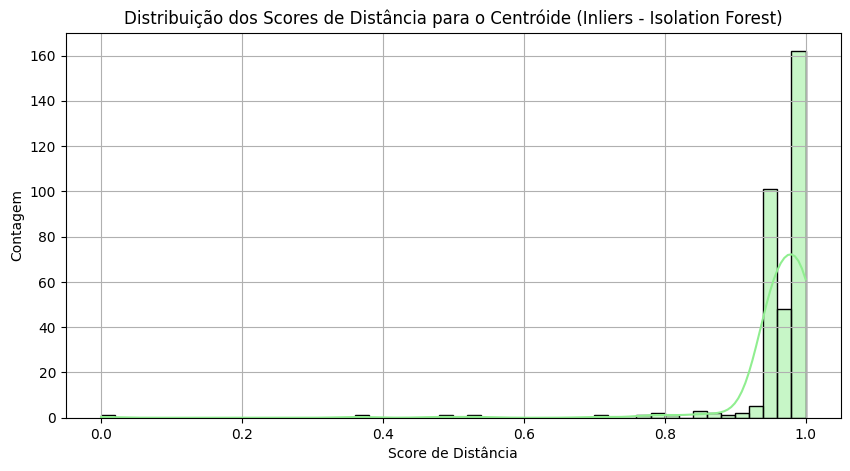

Calculando distância média para os 10 vizinhos mais próximos (entre inliers)...
Score k-NN aplicado a 333 inliers.
Média dos scores k-NN (normalizado): 0.8772


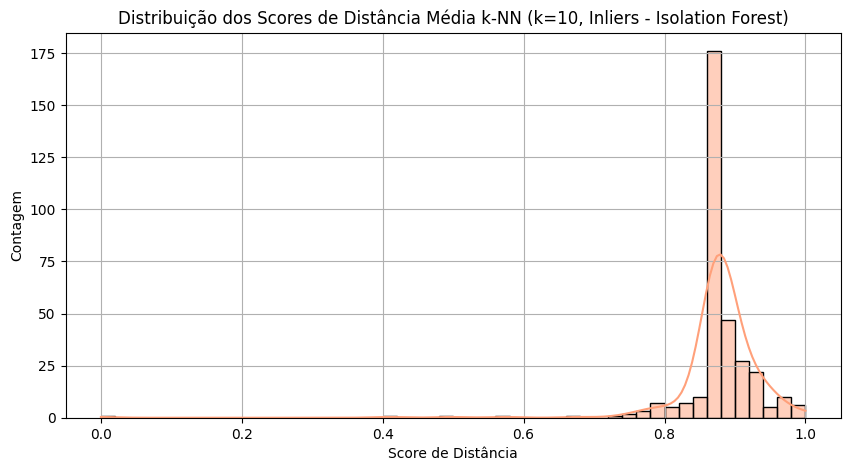


--- Criando DataFrame com todos os scores ---

Resumo estatístico dos scores:


,oc_svm_score,iso_forest_score,dbs_centroid_score,dbs_knn_score
count,351.000000,351.000000,333.000000,333.000000
mean,0.009955,0.018728,0.962840,0.877218
std,0.565319,0.008914,0.080510,0.072865
min,-9.961257,-0.011924,0.000000,0.000000
25%,0.008116,0.014137,0.953632,0.874623
50%,0.033428,0.021202,0.966540,0.874694
75%,0.054541,0.024919,0.995244,0.896317
max,0.429765,0.033763,1.000000,1.000000



🏆 Top 10 empresas com maior score final (apenas inliers):


,empresa,media_final
0,GoodStorage,0.999483
1,Safira Holding,0.999229
2,Sou SERAC,0.998932
3,minu.co,0.998800
4,Simpar,0.998668
5,Rede Ápice,0.998429
6,JHSF,0.993239
7,ília,0.990608
8,Intelipost,0.990608
9,Leega,0.990506



--- EXPLICABILIDADE DO MODELO ---

🧠 Visualização 1: Projeção PCA com Cores por Score Final
Este gráfico mostra uma redução de dimensionalidade do dataset vetorizado (PCA),
permitindo visualizar se há agrupamento natural entre empresas de alto e baixo score final.
As cores representam o valor do score final médio de cada empresa.


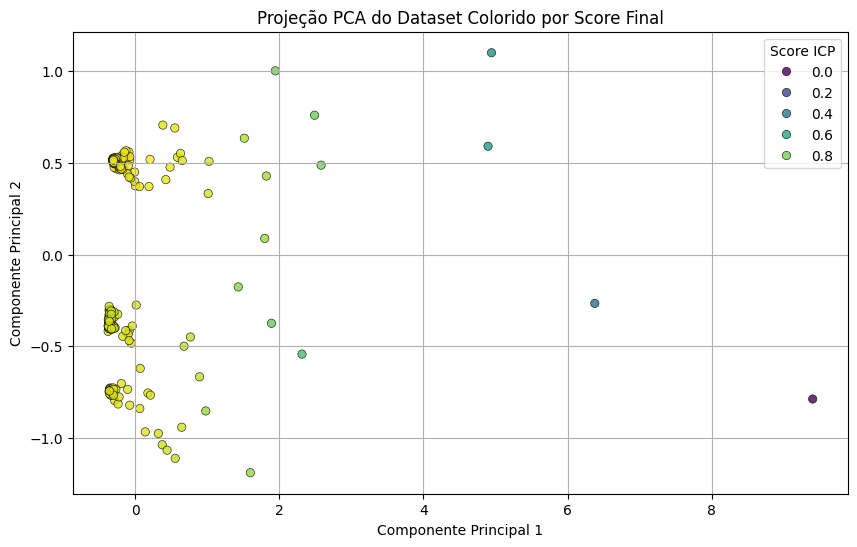


🧠 Visualização 2: Boxplot de Funcionários por Faixa de Score
Este gráfico compara a quantidade de funcionários das empresas agrupadas em três faixas:
Baixo, Médio e Alto score final.
Ele ajuda a investigar se empresas com muitos ou poucos funcionários tendem a ser ICPs.


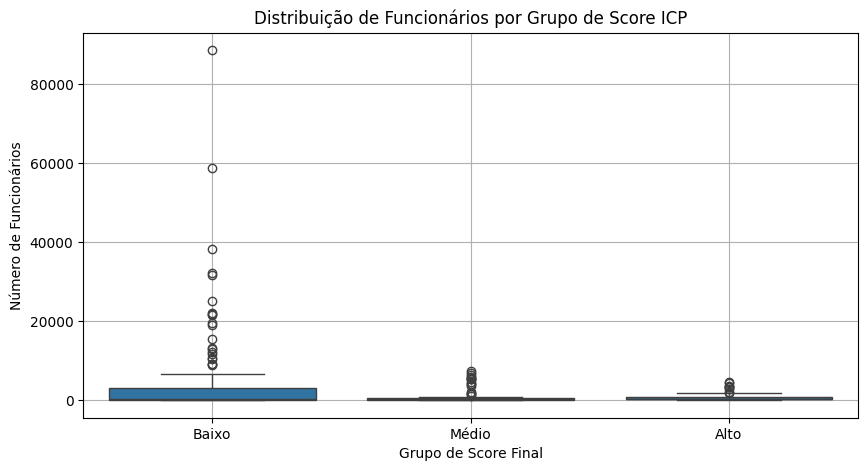


🧠 Visualização 3: Empresas com Maiores e Menores Scores
Essas tabelas mostram as 5 empresas com maior score final (ICP mais forte)
e as 5 com menor score final (possíveis outliers ou menos alinhadas ao perfil ideal).

📈 Top 5 empresas ICP:


,empresa,media_final
181,GoodStorage,0.999483
319,Safira Holding,0.999229
157,Sou SERAC,0.998932
218,minu.co,0.998800
129,Simpar,0.998668



📉 Bottom 5 empresas (possíveis outliers):


,empresa,media_final
130,JBS,0.000000
26,Atacadão,0.371515
263,Gerdau,0.484298
114,Dasa,0.542563
254,Hospital Albert Einstein,0.698863



Fluxo completo executado.


In [ ]:
#TOTALPASS
csv_file_path = '/content/drive/MyDrive/TCC/Dados/TotalPass/TotalPass Data.csv'
run_icp_analysis(csv_file_path)

Starting ICP analysis for: /content/drive/MyDrive/TCC/Dados/Unimed/Unimed Data.csv
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Início do Pré-processamento (ajustado às suas colunas) ---

Colunas após renomear: ['empresa', 'razão_social', 'cnpj', 'capital_social', 'intervalo_de_capital', 'segmento', 'funcionários', 'intervalo_de_funcionários', 'localização', 'job_industry_collection', 'linkedin', 'job_functions_collection', 'unique_segmento', 'contagem_de_segmento', 'top_segmentos', 'unnamed:_15']

Colunas removidas (ruído/inelegíveis): ['empresa', 'razão_social', 'cnpj', 'intervalo_de_capital', 'intervalo_de_funcionários', 'linkedin', 'unique_segmento']
Coluna 'localização' separada em 'cidade' e 'estado'.
Coluna 'capital_social' limpa e convertida para numérica.
Coluna 'funcionários' limpa e convertida para numérica.

Colunas ignoradas (fora do modelo): ['job_industry_collection', 'job_functions_c

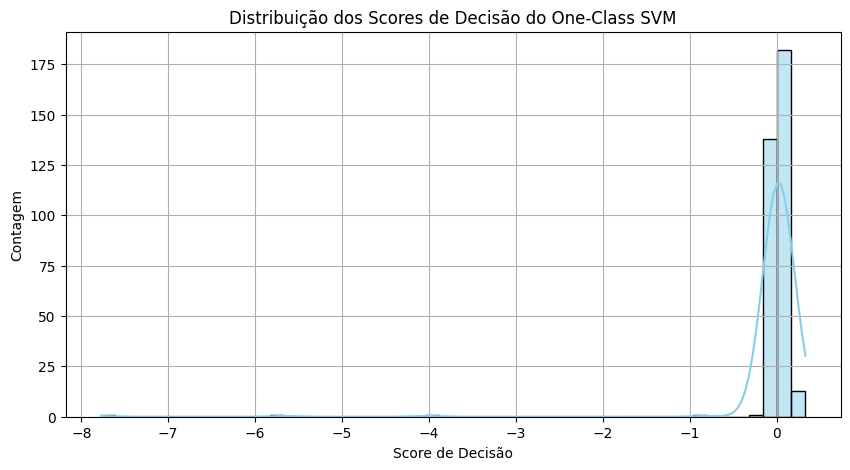


--- Modelo Isolation Forest (OCC) ---
Mínimo score Isolation Forest: -0.0151
Máximo score Isolation Forest: 0.0243
Média score Isolation Forest: 0.0124
Empresas classificadas como 'anomalias' pelo Isolation Forest: 17 de 338


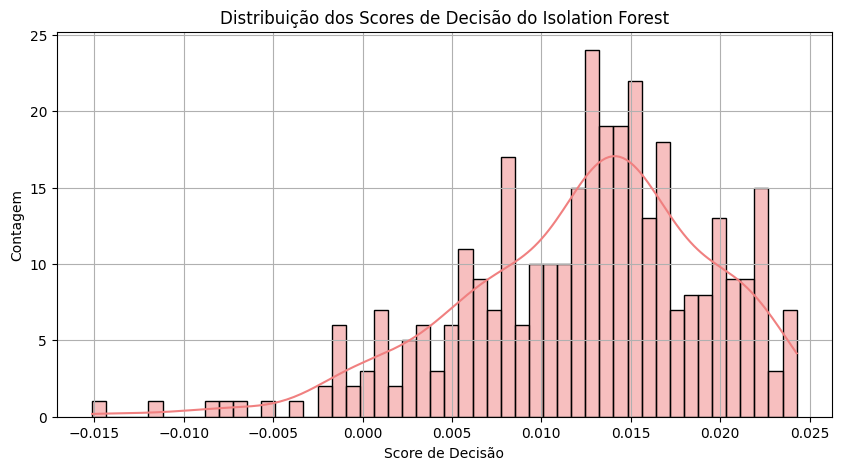


--- DBS aplicado somente aos Inliers do Isolation Forest ---
Score centróide aplicado a 321 inliers.
Média dos scores centróide (normalizado): 0.9788


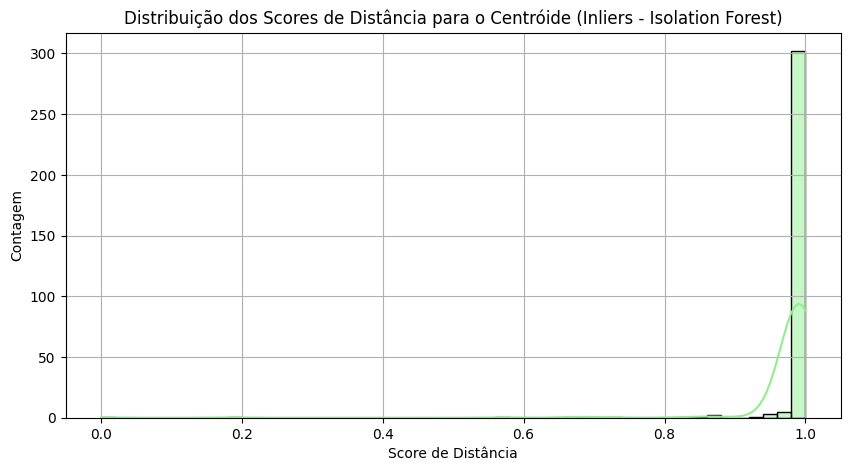

Calculando distância média para os 10 vizinhos mais próximos (entre inliers)...
Score k-NN aplicado a 321 inliers.
Média dos scores k-NN (normalizado): 0.9410


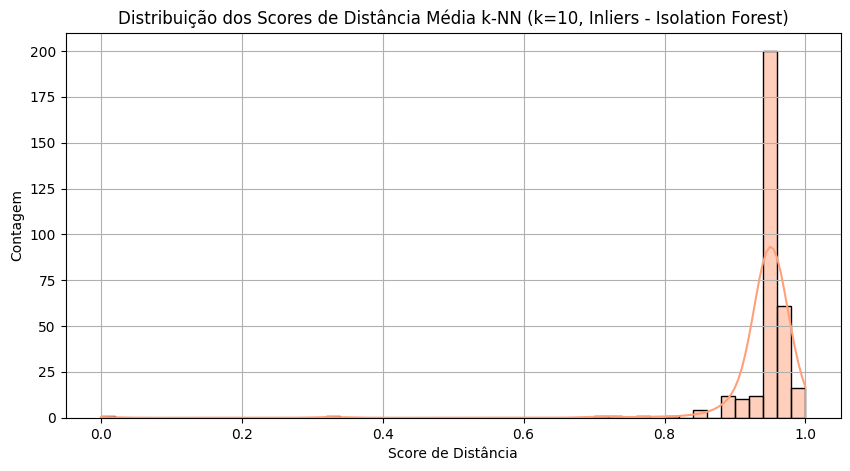


--- Criando DataFrame com todos os scores ---

Resumo estatístico dos scores:


,oc_svm_score,iso_forest_score,dbs_centroid_score,dbs_knn_score
count,338.000000,338.000000,321.000000,321.000000
mean,-0.025229,0.012428,0.978785,0.941020
std,0.572895,0.006925,0.081601,0.070098
min,-7.774794,-0.015126,0.000000,0.000000
25%,0.002231,0.008230,0.988708,0.947034
50%,0.012364,0.013364,0.990271,0.947116
75%,0.029951,0.016881,0.993359,0.959204
max,0.332520,0.024280,1.000000,1.000000



🏆 Top 10 empresas com maior score final (apenas inliers):


,empresa,media_final
0,MaisTODOS,0.999224
1,Internet Way®,0.999162
2,ENELO,0.998953
3,Basecol Mix,0.998904
4,Solinftec,0.998773
5,SGF Global,0.995571
6,Qive,0.995243
7,Cimoagro,0.994990
8,Shift,0.994978
9,Corebiz,0.994941



--- EXPLICABILIDADE DO MODELO ---

🧠 Visualização 1: Projeção PCA com Cores por Score Final
Este gráfico mostra uma redução de dimensionalidade do dataset vetorizado (PCA),
permitindo visualizar se há agrupamento natural entre empresas de alto e baixo score final.
As cores representam o valor do score final médio de cada empresa.


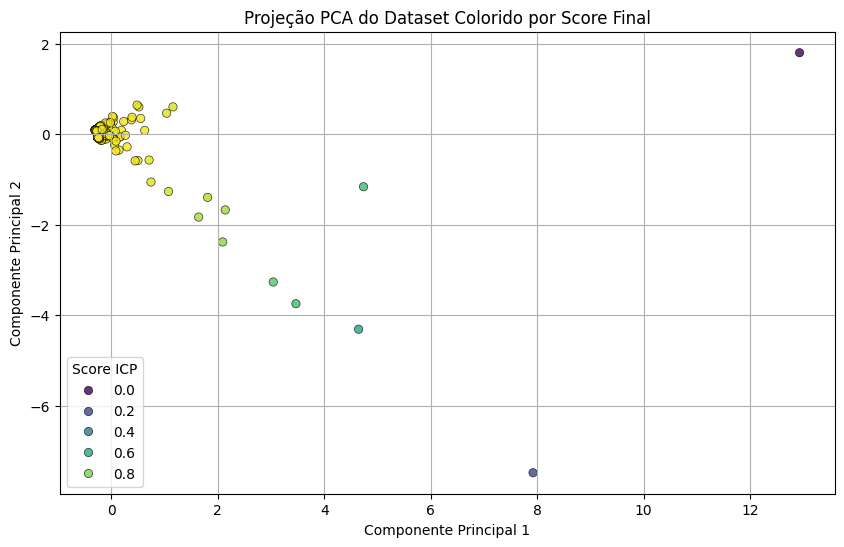


🧠 Visualização 2: Boxplot de Funcionários por Faixa de Score
Este gráfico compara a quantidade de funcionários das empresas agrupadas em três faixas:
Baixo, Médio e Alto score final.
Ele ajuda a investigar se empresas com muitos ou poucos funcionários tendem a ser ICPs.


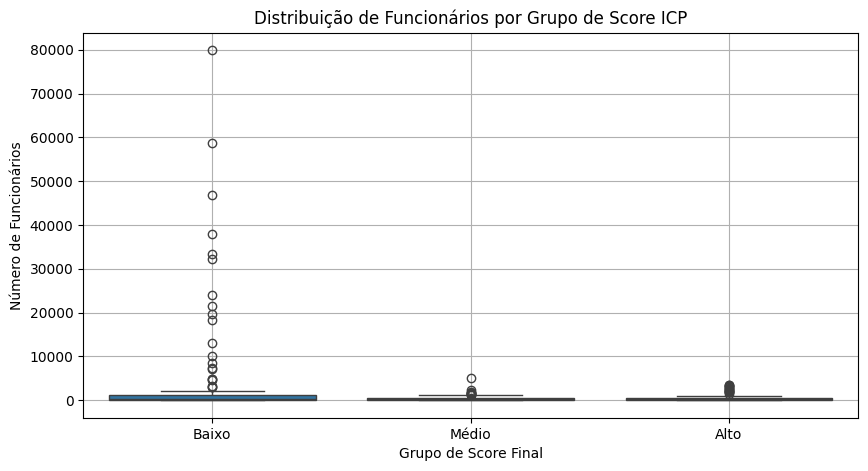


🧠 Visualização 3: Empresas com Maiores e Menores Scores
Essas tabelas mostram as 5 empresas com maior score final (ICP mais forte)
e as 5 com menor score final (possíveis outliers ou menos alinhadas ao perfil ideal).

📈 Top 5 empresas ICP:


,empresa,media_final
227,MaisTODOS,0.999224
181,Internet Way®,0.999162
173,ENELO,0.998953
198,Basecol Mix,0.998904
76,Solinftec,0.998773



📉 Bottom 5 empresas (possíveis outliers):


,empresa,media_final
177,Atacadão,0.000000
150,Continental,0.212279
197,Sherwin-Williams,0.593283
33,Riachuelo,0.689209
96,thyssenkrupp,0.690436



Fluxo completo executado.


In [ ]:
#UNIMED
csv_file_path = '/content/drive/MyDrive/TCC/Dados/Unimed/Unimed Data.csv'
run_icp_analysis(csv_file_path)

Starting ICP analysis for: /content/drive/MyDrive/TCC/Dados/Psicologia Viva/Psicologia Viva Data.csv
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Início do Pré-processamento (ajustado às suas colunas) ---

Colunas após renomear: ['empresa', 'razão_social', 'cnpj', 'capital_social', 'intervalo_de_capital', 'segmento', 'funcionários', 'intervalo_de_funcionários', 'localização', 'linkedin', 'uniue_segmento', 'contagem_de_segmento', 'top_segmento', 'unnamed:_13', 'unnamed_col', 'unnamed:_15', 'unnamed:_16', 'unnamed:_17', 'unnamed:_18', 'unnamed:_19', 'unnamed:_20', 'unnamed:_21', 'job_industry_collection', 'job_functions_collection']

Colunas removidas (ruído/inelegíveis): ['empresa', 'razão_social', 'cnpj', 'intervalo_de_capital', 'intervalo_de_funcionários', 'linkedin', 'unnamed_col']
Coluna 'localização' separada em 'cidade' e 'estado'.
Coluna 'capital_social' limpa e convertida para numérica.
Colun

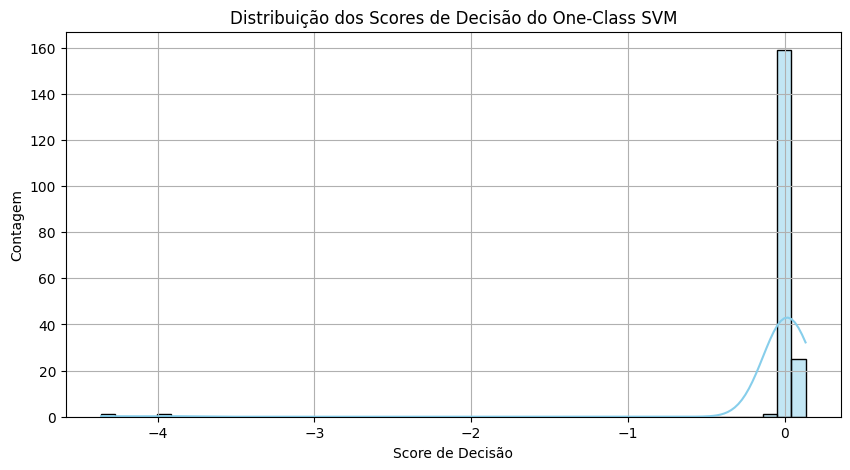


--- Modelo Isolation Forest (OCC) ---
Mínimo score Isolation Forest: -0.0115
Máximo score Isolation Forest: 0.0323
Média score Isolation Forest: 0.0156
Empresas classificadas como 'anomalias' pelo Isolation Forest: 10 de 187


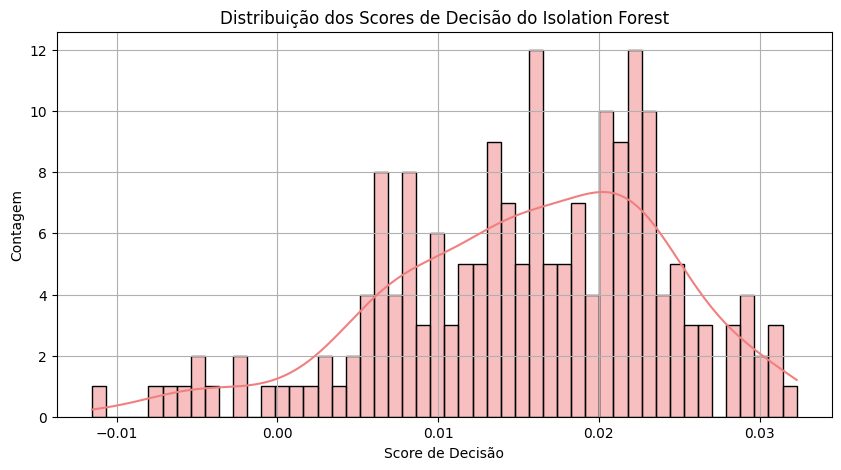


--- DBS aplicado somente aos Inliers do Isolation Forest ---
Score centróide aplicado a 177 inliers.
Média dos scores centróide (normalizado): 0.9698


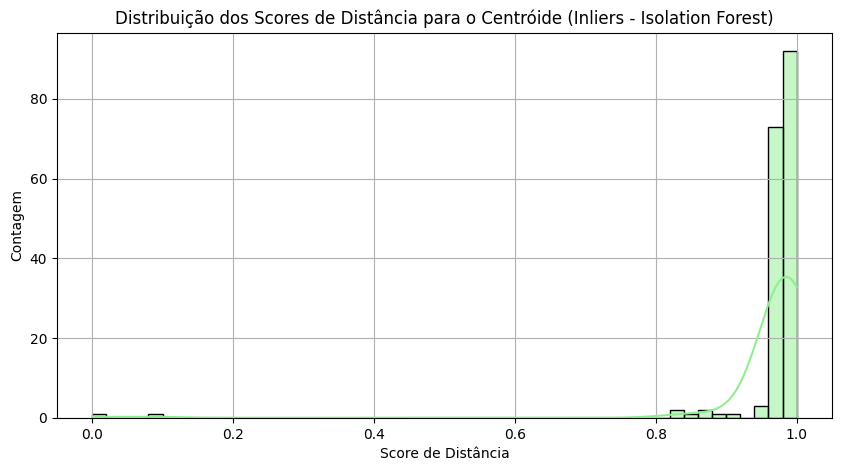

Calculando distância média para os 10 vizinhos mais próximos (entre inliers)...
Score k-NN aplicado a 177 inliers.
Média dos scores k-NN (normalizado): 0.9583


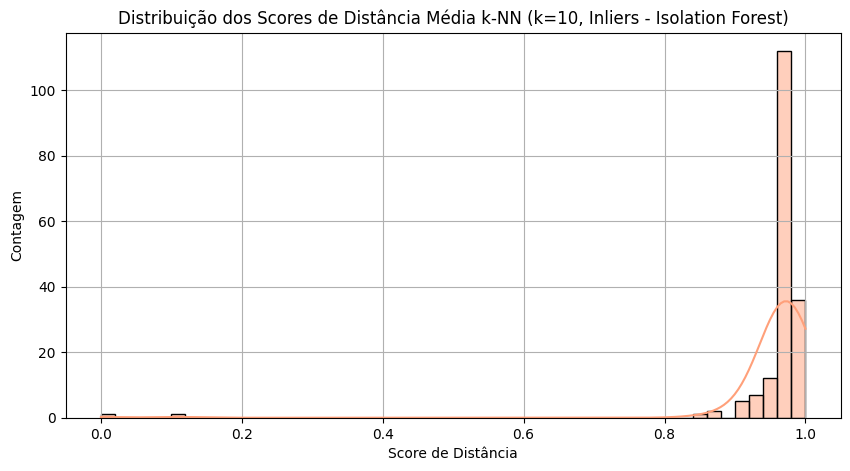


--- Criando DataFrame com todos os scores ---

Resumo estatístico dos scores:


,oc_svm_score,iso_forest_score,dbs_centroid_score,dbs_knn_score
count,187.000000,187.000000,1.770000e+02,1.770000e+02
mean,-0.027463,0.015589,9.698307e-01,9.583339e-01
std,0.430918,0.008631,1.026403e-01,9.927360e-02
min,-4.360490,-0.011531,1.110223e-16,-2.220446e-16
25%,0.000325,0.009903,9.768543e-01,9.671277e-01
50%,0.004902,0.016176,9.834854e-01,9.728230e-01
75%,0.013404,0.022025,9.960090e-01,9.728299e-01
max,0.133253,0.032305,1.000000e+00,1.000000e+00



🏆 Top 10 empresas com maior score final (apenas inliers):


,empresa,media_final
0,Barbosa Supermercados,0.999570
1,Avenida,0.999539
2,SRM ASSET,0.998820
3,Escola Villare,0.998777
4,Docket,0.998076
5,Procfit,0.997973
6,ROIT,0.997955
7,Empório Alex,0.997753
8,Laboratório Fantasma,0.997677
9,Rock Encantech,0.996474



--- EXPLICABILIDADE DO MODELO ---

🧠 Visualização 1: Projeção PCA com Cores por Score Final
Este gráfico mostra uma redução de dimensionalidade do dataset vetorizado (PCA),
permitindo visualizar se há agrupamento natural entre empresas de alto e baixo score final.
As cores representam o valor do score final médio de cada empresa.


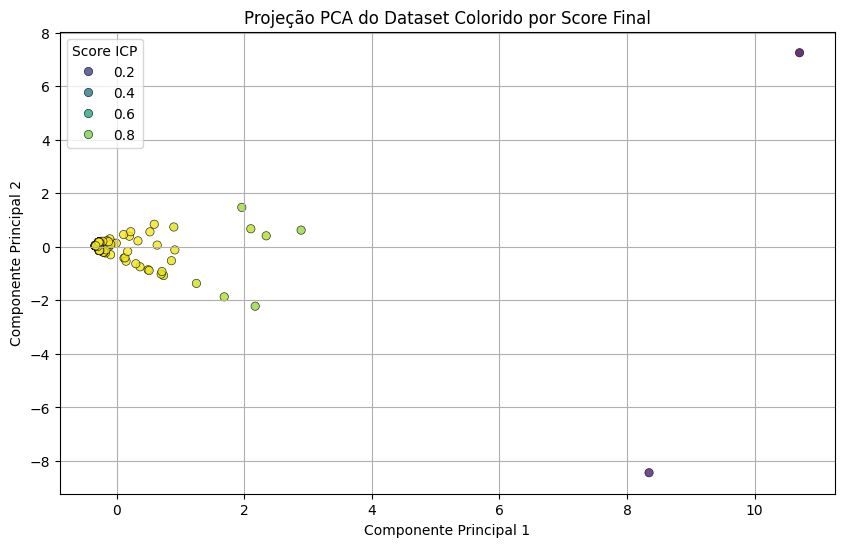


🧠 Visualização 2: Boxplot de Funcionários por Faixa de Score
Este gráfico compara a quantidade de funcionários das empresas agrupadas em três faixas:
Baixo, Médio e Alto score final.
Ele ajuda a investigar se empresas com muitos ou poucos funcionários tendem a ser ICPs.


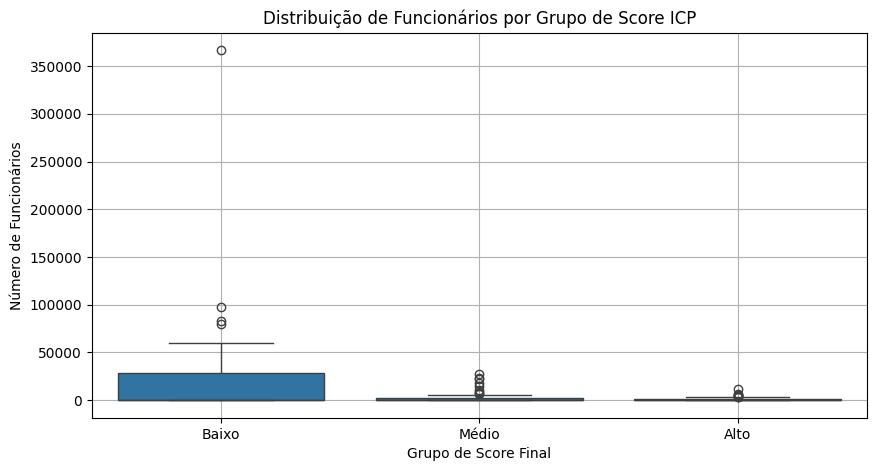


🧠 Visualização 3: Empresas com Maiores e Menores Scores
Essas tabelas mostram as 5 empresas com maior score final (ICP mais forte)
e as 5 com menor score final (possíveis outliers ou menos alinhadas ao perfil ideal).

📈 Top 5 empresas ICP:


,empresa,media_final
23,Barbosa Supermercados,0.999570
167,Avenida,0.999539
44,SRM ASSET,0.998820
100,Escola Villare,0.998777
102,Docket,0.998076



📉 Bottom 5 empresas (possíveis outliers):


,empresa,media_final
35,Banco Bradesco,4.440892e-17
89,EY,9.251397e-02
73,Atento,8.356786e-01
95,Atacadão,8.422563e-01
76,Localiza&Co,8.583021e-01



Fluxo completo executado.


In [ ]:
#PSICOLOGIA VIVA
csv_file_path = '/content/drive/MyDrive/TCC/Dados/Psicologia Viva/Psicologia Viva Data.csv'
run_icp_analysis(csv_file_path)

Starting ICP analysis for: /content/drive/MyDrive/TCC/Dados/Swile/Swile Data.csv
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Início do Pré-processamento (ajustado às suas colunas) ---

Colunas após renomear: ['empresa', 'razão_social', 'cnpj', 'capital_social', 'intervalo_de_capital', 'segmento', 'funcionários', 'intervalo_de_funcionários', 'localização', 'job_industry_collection', 'job_functions_collection', 'linkedin', 'unique_segmento', 'contagem_de_segmento', 'top_segmentos', 'unnamed:_15']

Colunas removidas (ruído/inelegíveis): ['empresa', 'razão_social', 'cnpj', 'intervalo_de_capital', 'intervalo_de_funcionários', 'linkedin', 'unique_segmento']
Coluna 'localização' separada em 'cidade' e 'estado'.
Coluna 'capital_social' limpa e convertida para numérica.
Coluna 'funcionários' limpa e convertida para numérica.

Colunas ignoradas (fora do modelo): ['job_industry_collection', 'job_functions_col

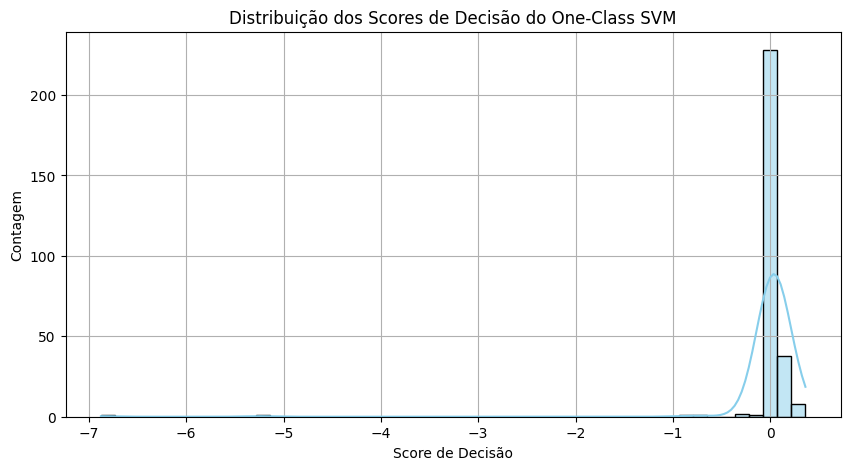


--- Modelo Isolation Forest (OCC) ---
Mínimo score Isolation Forest: -0.0144
Máximo score Isolation Forest: 0.0326
Média score Isolation Forest: 0.0165
Empresas classificadas como 'anomalias' pelo Isolation Forest: 14 de 281


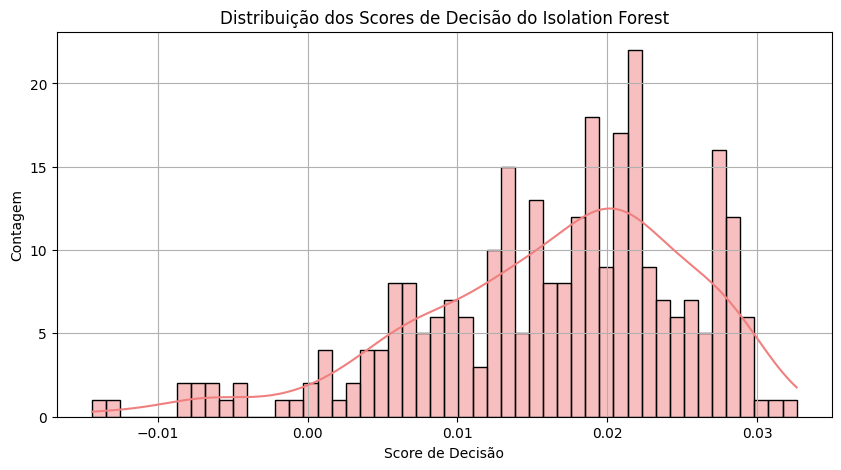


--- DBS aplicado somente aos Inliers do Isolation Forest ---
Score centróide aplicado a 267 inliers.
Média dos scores centróide (normalizado): 0.9288


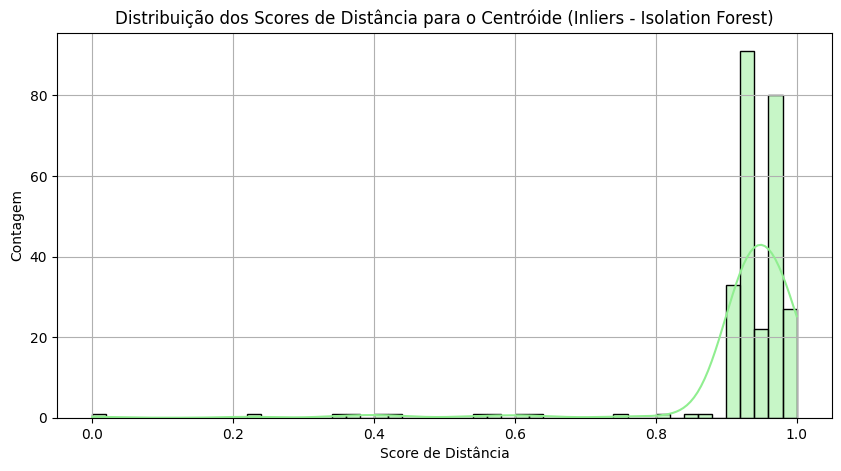

Calculando distância média para os 10 vizinhos mais próximos (entre inliers)...
Score k-NN aplicado a 267 inliers.
Média dos scores k-NN (normalizado): 0.7268


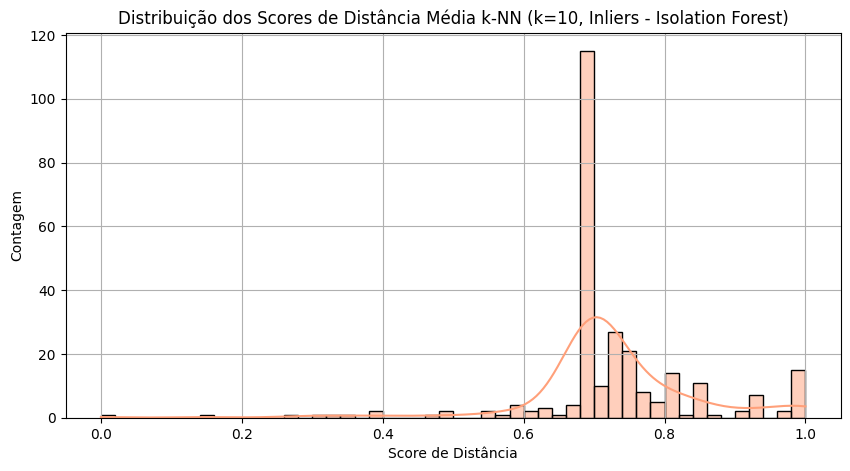


--- Criando DataFrame com todos os scores ---

Resumo estatístico dos scores:


,oc_svm_score,iso_forest_score,dbs_centroid_score,dbs_knn_score
count,281.000000,281.000000,267.000000,2.670000e+02
mean,-0.005336,0.016469,0.928798,7.267835e-01
std,0.526742,0.008948,0.111906,1.261842e-01
min,-6.877310,-0.014379,0.000000,1.110223e-16
25%,0.006541,0.011343,0.923559,6.939127e-01
50%,0.031286,0.018263,0.939254,6.939402e-01
75%,0.049032,0.022503,0.975749,7.549665e-01
max,0.362331,0.032638,1.000000,1.000000e+00



🏆 Top 10 empresas com maior score final (apenas inliers):


,empresa,media_final
0,BYX,0.998711
1,Certsys,0.998709
2,Tax.Co,0.998703
3,Sem nome,0.998672
4,Vai Voando,0.998608
5,Better Now,0.998516
6,Fluencypass,0.998492
7,Construmarket,0.998462
8,NaN,0.998370
9,Empiricus,0.998335



--- EXPLICABILIDADE DO MODELO ---

🧠 Visualização 1: Projeção PCA com Cores por Score Final
Este gráfico mostra uma redução de dimensionalidade do dataset vetorizado (PCA),
permitindo visualizar se há agrupamento natural entre empresas de alto e baixo score final.
As cores representam o valor do score final médio de cada empresa.


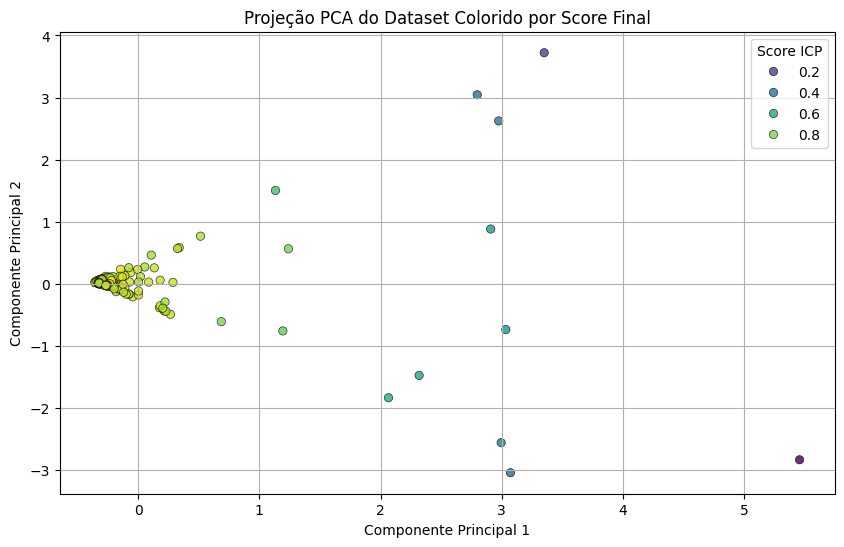


🧠 Visualização 2: Boxplot de Funcionários por Faixa de Score
Este gráfico compara a quantidade de funcionários das empresas agrupadas em três faixas:
Baixo, Médio e Alto score final.
Ele ajuda a investigar se empresas com muitos ou poucos funcionários tendem a ser ICPs.


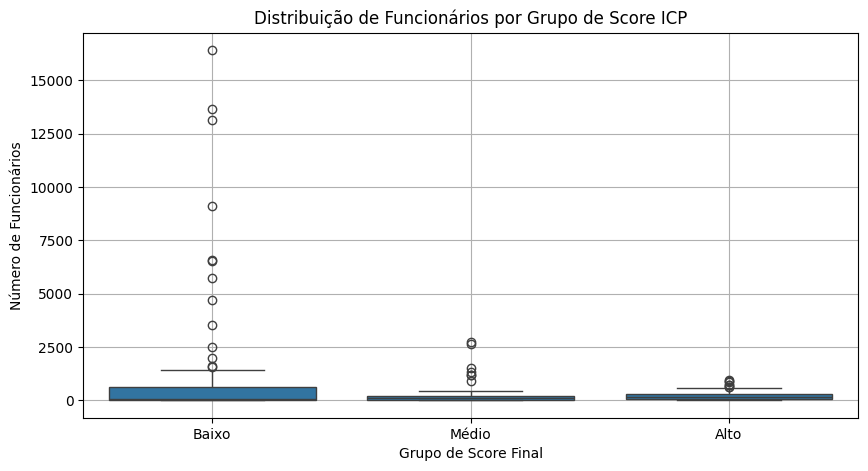


🧠 Visualização 3: Empresas com Maiores e Menores Scores
Essas tabelas mostram as 5 empresas com maior score final (ICP mais forte)
e as 5 com menor score final (possíveis outliers ou menos alinhadas ao perfil ideal).

📈 Top 5 empresas ICP:


,empresa,media_final
84,BYX,0.998711
59,Certsys,0.998709
12,Tax.Co,0.998703
115,Sem nome,0.998672
85,Vai Voando,0.998608



📉 Bottom 5 empresas (possíveis outliers):


,empresa,media_final
279,Brisanet Telecomunicações,2.220446e-17
90,Reply,2.076166e-01
94,Mitre Realty,3.446114e-01
267,Softtek,3.589444e-01
23,Egis,3.983739e-01



Fluxo completo executado.


In [ ]:
#SWILE
csv_file_path = '/content/drive/MyDrive/TCC/Dados/Swile/Swile Data.csv'
run_icp_analysis(csv_file_path)